In [2]:
from space_exploration.beans.training_bean import Training
from space_exploration.training.training import ModelTraining
from space_exploration.training.training_benchmark_keys import TrainingBenchmarkKeys
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def load_benchmarks(runs_id, key):
    benchmarks = [fetch_one_bench(run_id) for run_id in runs_id]
    all_sub_benchmark = [b.benchmarks[key] for b in benchmarks if key in b.benchmarks]
    return pd.concat(all_sub_benchmark, ignore_index=True)
    
def fetch_one_bench(run_id):
    bean = Training.get_training_or_fail(run_id)
    training = ModelTraining.from_training_bean(bean)
    benchmark = training.get_benchmark()
    benchmark.load()
    return benchmark

def load_ds_benchmarks(datasets, key):
    benchmarks = [fetch_one_ds_bench(names) for names in datasets]
    all_sub_benchmark = [b.benchmarks[key] for b in benchmarks if key in b.benchmarks]
    return pd.concat(all_sub_benchmark, ignore_index=True)


import numpy as np
from space_exploration.beans.dataset_bean import Dataset
from space_exploration.dataset.transforms.AllTransforms import TransformationReferences
from space_exploration.dataset.benchmarks.benchmark_keys import DatasetBenchmarkKeys

def fetch_one_ds_bench(dataset_name):
    dataset = Dataset.get_dataset_or_fail(dataset_name)
    benchmark = dataset.benchmark
    return benchmark


In [3]:
datasets = ["re200-sr1etot", "re200-sr05etot", "re200-sr005etot", "paper-train"]
df = load_ds_benchmarks(datasets, DatasetBenchmarkKeys.VELOCITY_MEAN_ALONG_Y)

In [4]:
df

,velocity_mean_along_y,component,y_dimension,dataset_id,name
0,-1.822986e-15,u,0.555505,23,re200-sr1etot
1,9.277591e-01,u,1.667099,23,re200-sr1etot
2,1.847760e+00,u,2.780451,23,re200-sr1etot
3,2.752267e+00,u,3.896738,23,re200-sr1etot
4,3.629374e+00,u,5.017153,23,re200-sr1etot
...,...,...,...,...,...
760,8.131400e-12,w,170.791114,20,paper-train
761,7.310457e-11,w,177.222271,20,paper-train
762,-4.416403e-11,w,183.698020,20,paper-train
763,-8.326682e-11,w,190.205892,20,paper-train


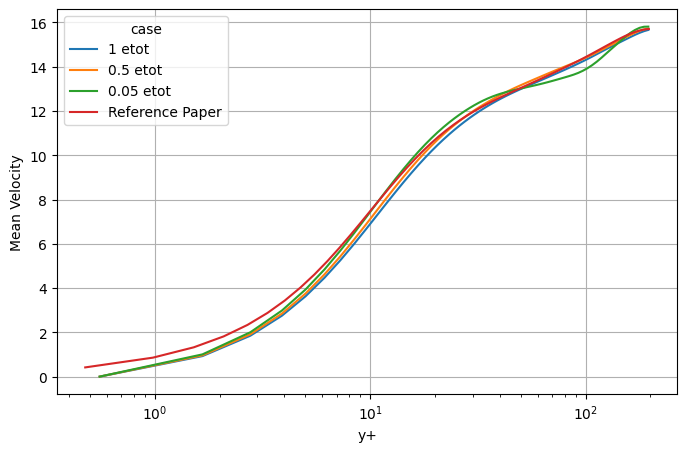

In [5]:
datasets = ["re200-sr1etot", "re200-sr05etot", "re200-sr005etot", "paper-train"]
df = load_ds_benchmarks(datasets, DatasetBenchmarkKeys.VELOCITY_MEAN_ALONG_Y)
df = df.rename(columns={
    "velocity_mean_along_y": "Mean Velocity",
    "y_dimension": "y+",
    "name": "case"
})

name_map = {
    "re200-sr1etot": "1 etot",
    "re200-sr05etot": "0.5 etot",
    "re200-sr005etot": "0.05 etot",
    "paper-train": "Reference Paper"
}
df["case"] = df["case"].replace(name_map)

plt.figure(figsize=(8, 5))
sns.lineplot(data=df.where(df["component"] == "u"), x="y+", y="Mean Velocity", hue="case")
plt.grid()
plt.xscale('log')
plt.show()

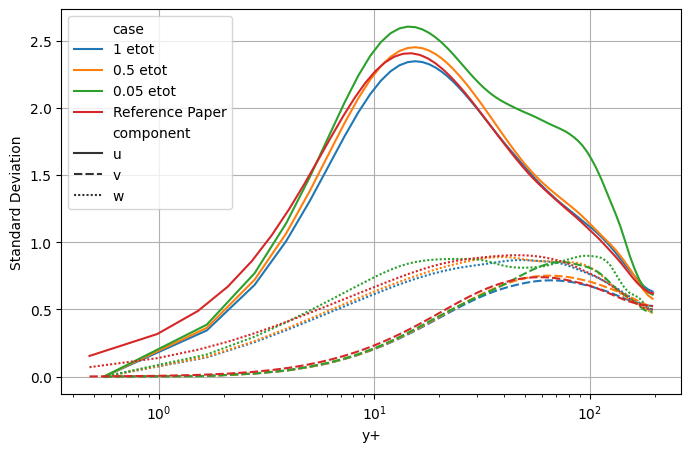

In [6]:
datasets = ["re200-sr1etot", "re200-sr05etot", "re200-sr005etot", "paper-train"]
df = load_ds_benchmarks(datasets, DatasetBenchmarkKeys.VELOCITY_STD_ALONG_Y)
df = df.rename(columns={
    "velocity_std_along_y": "Standard Deviation",
    "y_dimension": "y+",
    "name": "case"
})

name_map = {
    "re200-sr1etot": "1 etot",
    "re200-sr05etot": "0.5 etot",
    "re200-sr005etot": "0.05 etot",
    "paper-train": "Reference Paper"
}
df["case"] = df["case"].replace(name_map)

plt.figure(figsize=(8, 5))
sns.lineplot(data=df, x="y+", y="Standard Deviation", hue="case", style="component")
plt.grid()
plt.xscale('log')
plt.show()

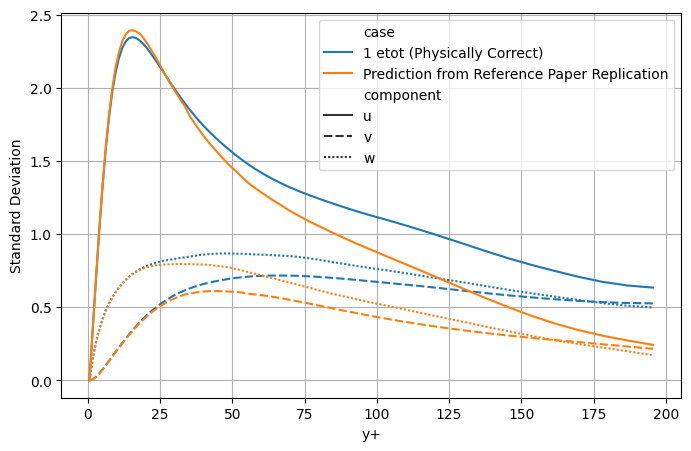

In [8]:
datasets = ["re200-sr1etot", "prediction-a67107ff"]
df = load_ds_benchmarks(datasets, DatasetBenchmarkKeys.VELOCITY_STD_ALONG_Y)
df = df.rename(columns={
    "velocity_std_along_y": "Standard Deviation",
    "y_dimension": "y+",
    "name": "case"
})

name_map = {
    "re200-sr1etot": "1 etot (Physically Correct)",
    "prediction-a67107ff": "Prediction from Reference Paper Replication",
}
df["case"] = df["case"].replace(name_map)

plt.figure(figsize=(8, 5))
sns.lineplot(data=df, x="y+", y="Standard Deviation", hue="case", style="component")
plt.grid()
plt.show()

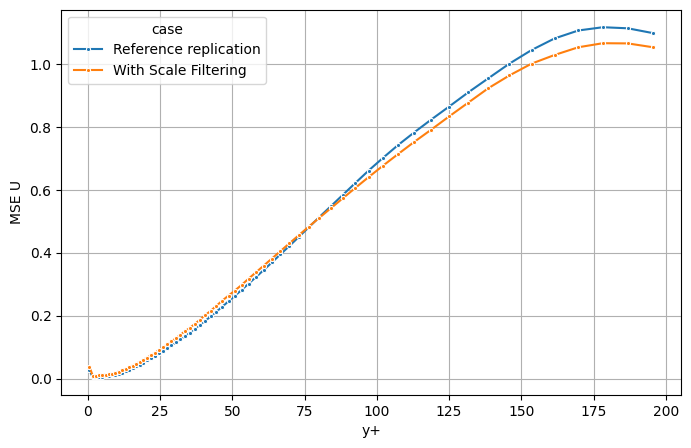

In [148]:
runs_id = ["a67107ff6b9c4ab6ad48546e70384b88", "80e0b5c425024897911a89ad08861140"]

bm = load_benchmarks(runs_id, TrainingBenchmarkKeys.PAPER_LIKE_MSE_ALONG_Y) 

bm = bm.rename(columns={
    "paper_like_mse_along_y": "MSE U",
    "y_dimension": "y+",
    "name": "case"
})

name_map = {
    "paper-normalized": "Reference replication",
    "80e0b5c425024897911a89ad08861140-scale_filtering-renormalized": "With Scale Filtering",
}
bm["case"] = bm["case"].replace(name_map)

plt.figure(figsize=(8, 5))
sns.lineplot(data=bm.where(bm["component"] == "u"), x="y+", y="MSE U", hue="case", marker='.')
plt.grid()
plt.show()

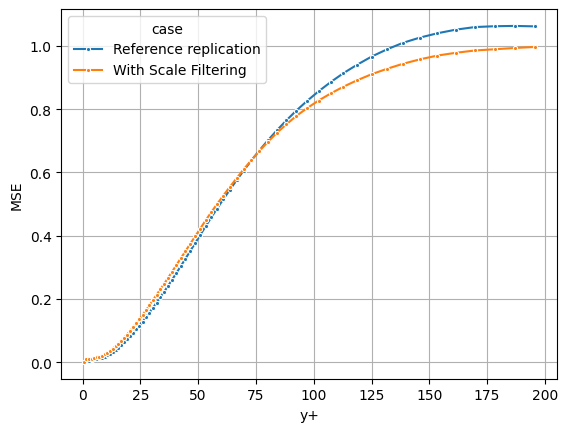

In [106]:
sns.lineplot(data=bm.where(bm["component"] == "v"), x="y+", y="MSE", hue="case", marker='.')
plt.grid()
plt.show()

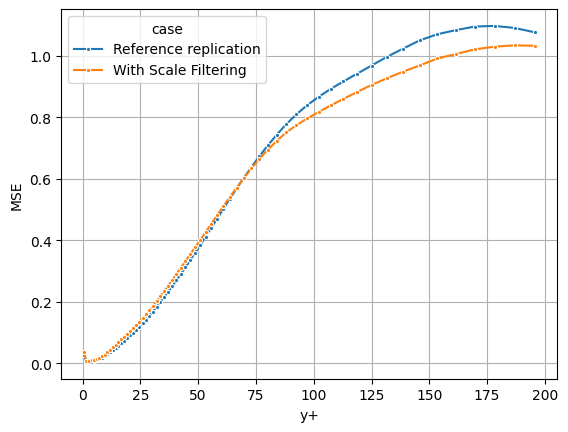

In [105]:
sns.lineplot(data=bm.where(bm["component"] == "w"), x="y+", y="MSE", hue="case", marker='.')
plt.grid()
plt.show()

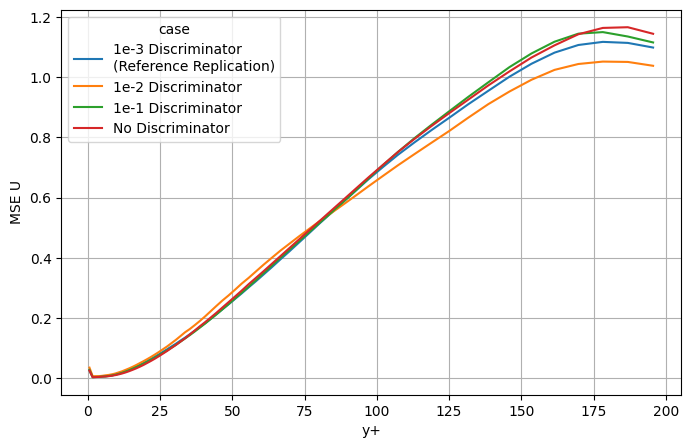

In [147]:
runs_id = ["a67107ff6b9c4ab6ad48546e70384b88", "d8daaee5ee71442686a2017b3972dded", "c1131be2732c4ead94612f31d25d6931", "b1fedf978ca1471ea2b641e4774c256a"]

bm = load_benchmarks(runs_id, TrainingBenchmarkKeys.PAPER_LIKE_MSE_ALONG_Y)
bm = bm.rename(columns={
    "paper_like_mse_along_y": "MSE U",
    "y_dimension": "y+",
    "name": "case"
})
name_map = {
    "paper-normalized": "1e-3 Discriminator\n(Reference Replication)",
    "d8daaee5ee71442686a2017b3972dded-discri:1e-2": "1e-2 Discriminator",
    "c1131be2732c4ead94612f31d25d6931-discri:1e-1": "1e-1 Discriminator",
    "b1fedf978ca1471ea2b641e4774c256a-wall decoder only": "No Discriminator",
}
bm["case"] = bm["case"].replace(name_map)

plt.figure(figsize=(8, 5))
sns.lineplot(data=bm.where(bm["component"] == "u"), x="y+", y="MSE U", hue="case")
plt.grid(True)
plt.show()

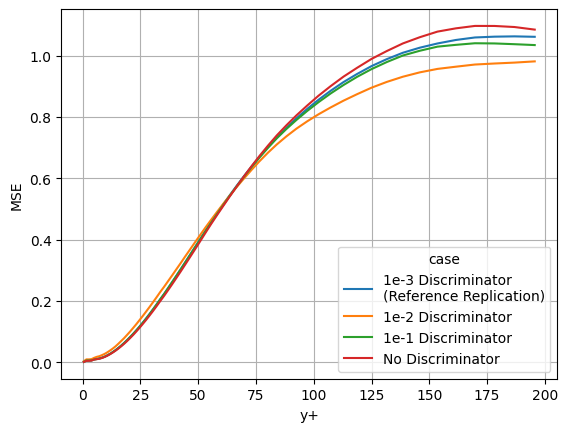

In [113]:
sns.lineplot(data=bm.where(bm["component"] == "v"), x="y+", y="MSE", hue="case")
plt.grid(True)
plt.show()

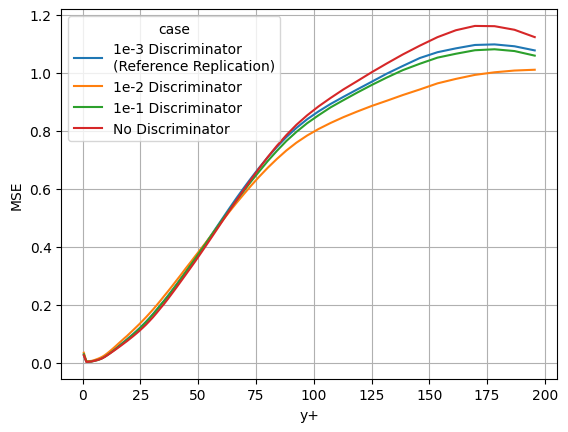

In [114]:
sns.lineplot(data=bm.where(bm["component"] == "w"), x="y+", y="MSE", hue="case")
plt.grid(True)
plt.show()

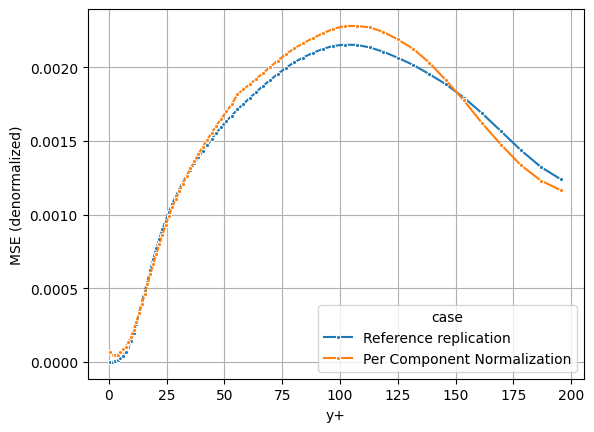

In [140]:
runs_id = ["a67107ff6b9c4ab6ad48546e70384b88", "8b9eb377eef1489f8ec74a5c0b9a6bd5"]

bm = load_benchmarks(runs_id, TrainingBenchmarkKeys.REAL_MSE_ALONG_Y)
bm = bm.rename(columns={
    "real_mse_along_y": "MSE (denormalized)",
    "y_dimension": "y+",
    "name": "case"
})
name_map = {
    "paper-normalized": "Reference replication",
    "normlized-comp": "Per Component Normalization",
}
bm["case"] = bm["case"].replace(name_map)

sns.lineplot(data=bm.where(bm["component"] == "u"), x="y+", y="MSE (denormalized)", hue="case", marker='.')
plt.grid(True)
plt.show()

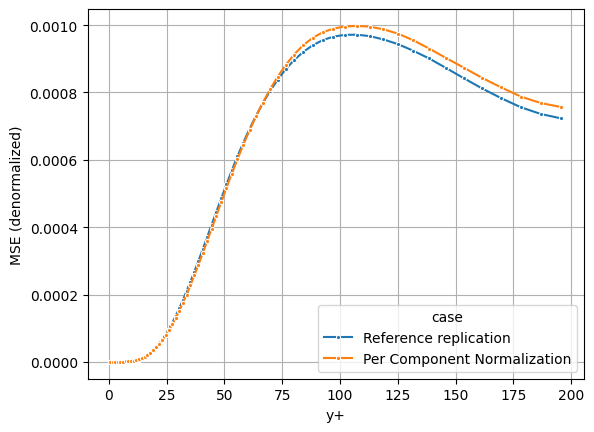

In [117]:
sns.lineplot(data=bm.where(bm["component"] == "v"), x="y+", y="MSE (denormalized)", hue="case", marker='.')
plt.grid(True)
plt.show()

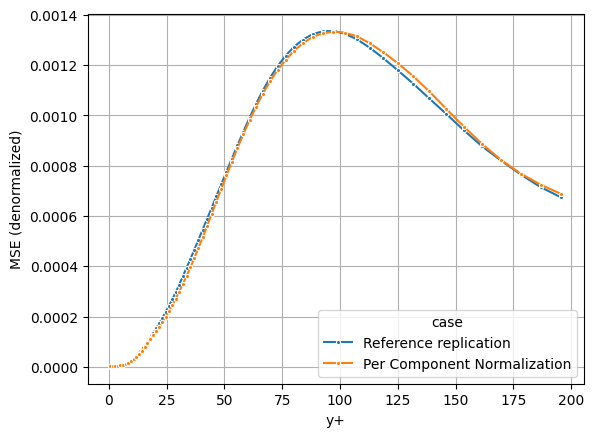

In [119]:
sns.lineplot(data=bm.where(bm["component"] == "w"), x="y+", y="MSE (denormalized)", hue="case", marker='.')
plt.grid(True)
plt.show()

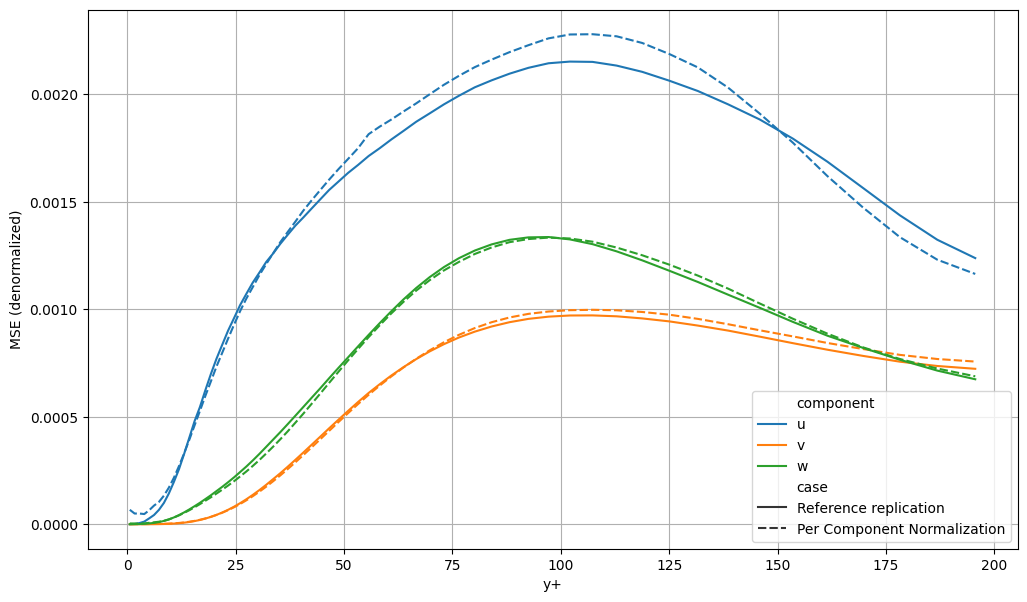

In [145]:
plt.figure(figsize=(12, 7))
sns.lineplot(data=bm, x="y+", y="MSE (denormalized)", hue="component", style="case")
plt.grid(True)
plt.show()

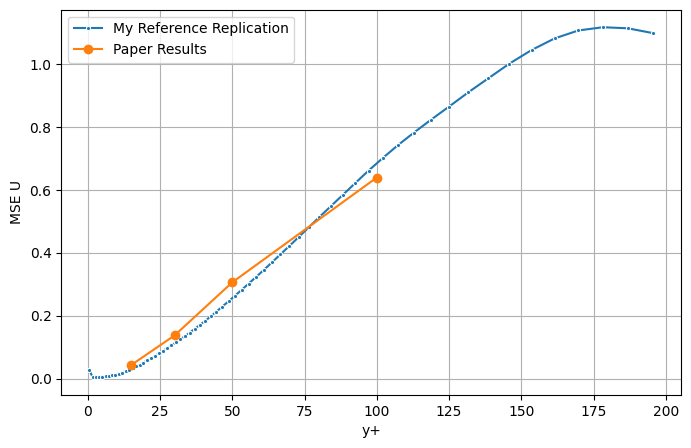

In [138]:
runs_id = ["a67107ff6b9c4ab6ad48546e70384b88"]

bm = load_benchmarks(runs_id, TrainingBenchmarkKeys.PAPER_LIKE_MSE_ALONG_Y)
bm = bm.rename(columns={
    "paper_like_mse_along_y": "MSE U",
    "y_dimension": "y+",
    "name": "case"
})
name_map = {
    "paper-normalized": "My Reference Replication",
}
bm["case"] = bm["case"].replace(name_map)

plt.figure(figsize=(8, 5))
sns.lineplot(data=bm.where(bm["component"] == "u"), x="y+", y="MSE U", hue="case", marker='.')
plt.plot([15, 30, 50, 100], [0.043, 0.137, 0.306, 0.639], label="Paper Results", marker='o')
plt.legend()
plt.grid(True)
plt.show()

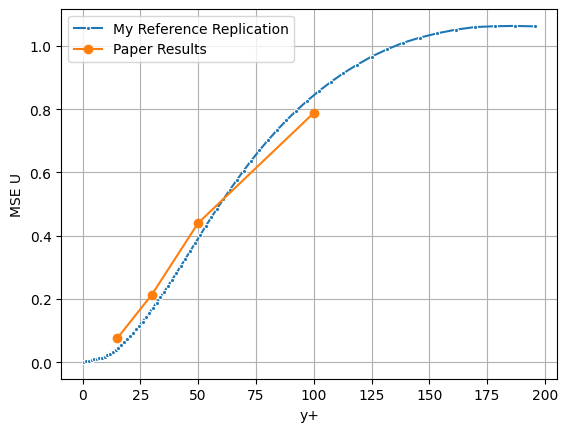

In [122]:
runs_id = ["a67107ff6b9c4ab6ad48546e70384b88"]

bm = load_benchmarks(runs_id, TrainingBenchmarkKeys.PAPER_LIKE_MSE_ALONG_Y)
bm = bm.rename(columns={
    "paper_like_mse_along_y": "MSE U",
    "y_dimension": "y+",
    "name": "case"
})
name_map = {
    "paper-normalized": "My Reference Replication",
}
bm["case"] = bm["case"].replace(name_map)

sns.lineplot(data=bm.where(bm["component"] == "v"), x="y+", y="MSE U", hue="case", marker='.')
plt.plot([15, 30, 50, 100], [0.076, 0.214, 0.440, 0.788], label="Paper Results", marker='o')
plt.legend()
plt.grid(True)
plt.show()

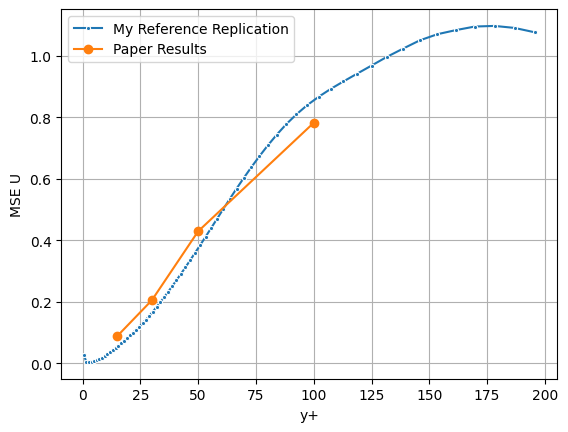

In [123]:
runs_id = ["a67107ff6b9c4ab6ad48546e70384b88"]

bm = load_benchmarks(runs_id, TrainingBenchmarkKeys.PAPER_LIKE_MSE_ALONG_Y)
bm = bm.rename(columns={
    "paper_like_mse_along_y": "MSE U",
    "y_dimension": "y+",
    "name": "case"
})
name_map = {
    "paper-normalized": "My Reference Replication",
}
bm["case"] = bm["case"].replace(name_map)

sns.lineplot(data=bm.where(bm["component"] == "w"), x="y+", y="MSE U", hue="case", marker='.')
plt.plot([15, 30, 50, 100], [0.088, 0.205, 0.429, 0.782], label="Paper Results", marker='o')
plt.legend()
plt.grid(True)
plt.show()

In [149]:
import numpy as np
from space_exploration.beans.dataset_bean import Dataset
from space_exploration.dataset.transforms.AllTransforms import TransformationReferences
dataset_name = "re200-sr1etot"
dataset = Dataset.get_dataset_or_fail(dataset_name)
ds = dataset.get_training_dataset(64, TransformationReferences.DEFAULT_UNCHANGED.transformation, TransformationReferences.DEFAULT_UNCHANGED.transformation, size=1000)
# ds = dataset.get_training_dataset(64, TransformationReferences.COMPONENT_NORMALIZE.transformation, TransformationReferences.Y_ALONG_COMPONENT_NORMALIZE.transformation, size=10)
xs = np.array([x.numpy() for x, y in ds])
ys = np.array([y.numpy() for x, y in ds])


⌛ Initializing Dataset...
X...
[########################################] | 100% Completed | 460.10 ms
Y...
[########################################] | 100% Completed | 5.01 ss


In [168]:
y_dim = dataset.channel.get_simulation_channel().y_dimension[:64] * 200

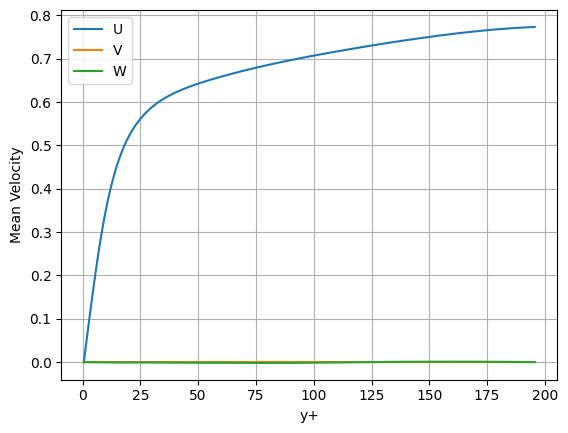

In [174]:

plt.plot(y_dim, ys.mean((0, 2, 4))[0], label="U")
plt.plot(y_dim, ys.mean((0, 2, 4))[1], label="V")
plt.plot(y_dim, ys.mean((0, 2, 4))[2], label="W")
plt.xlabel("y+")
plt.ylabel("Mean Velocity")
plt.legend()
plt.grid()
plt.show()

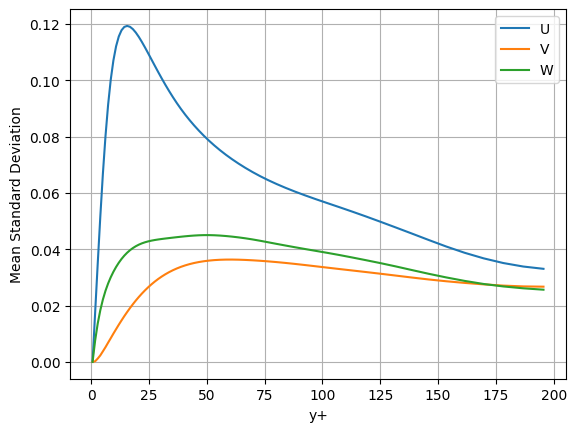

In [175]:
plt.plot(y_dim, ys.std((0, 2, 4))[0], label="U")
plt.plot(y_dim, ys.std((0, 2, 4))[1], label="V")
plt.plot(y_dim, ys.std((0, 2, 4))[2], label="W")
plt.xlabel("y+")
plt.ylabel("Mean Standard Deviation")
plt.legend()
plt.grid()
plt.show()

In [205]:
bm

,MSE U,component,y+,training_id,case
0,0.026105,u,0.555505,16,My Reference Replication
1,0.004175,u,1.667099,16,My Reference Replication
2,0.004429,u,2.780451,16,My Reference Replication
3,0.004620,u,3.896738,16,My Reference Replication
4,0.006069,u,5.017153,16,My Reference Replication
...,...,...,...,...,...
571,1.005626,w,161.500168,73,With Scale Filtering
572,1.021156,w,169.741053,73,With Scale Filtering
573,1.029721,w,178.211944,73,With Scale Filtering
574,1.034046,w,186.855558,73,With Scale Filtering


In [232]:
runs_id = ["a67107ff6b9c4ab6ad48546e70384b88", "d8daaee5ee71442686a2017b3972dded", "80e0b5c425024897911a89ad08861140"]

bm = load_benchmarks(runs_id, TrainingBenchmarkKeys.PAPER_LIKE_MSE_ALONG_Y)
bm = bm.rename(columns={
    "paper_like_mse_along_y": "MSE U",
    "y_dimension": "y+",
    "name": "case"
})
name_map = {
    "paper-normalized": "My Reference Replication",
    "d8daaee5ee71442686a2017b3972dded-discri:1e-2": "1e-2 Discriminator",
    "80e0b5c425024897911a89ad08861140-scale_filtering-renormalized": "With Scale Filtering",
    
}
bm["case"] = bm["case"].replace(name_map)

baseline = bm[bm["case"] == "My Reference Replication"].rename(columns={"MSE U": "baseline"})

bm = bm.merge(baseline[["y+", "baseline", "component"]], on=["y+", "component"])



In [233]:
baseline

,baseline,component,y+,training_id,case
0,0.026105,u,0.555505,16,My Reference Replication
1,0.004175,u,1.667099,16,My Reference Replication
2,0.004429,u,2.780451,16,My Reference Replication
3,0.004620,u,3.896738,16,My Reference Replication
4,0.006069,u,5.017153,16,My Reference Replication
...,...,...,...,...,...
187,1.083598,w,161.500168,16,My Reference Replication
188,1.095274,w,169.741053,16,My Reference Replication
189,1.097234,w,178.211944,16,My Reference Replication
190,1.090774,w,186.855558,16,My Reference Replication


<Axes: xlabel='y+', ylabel='baseline'>

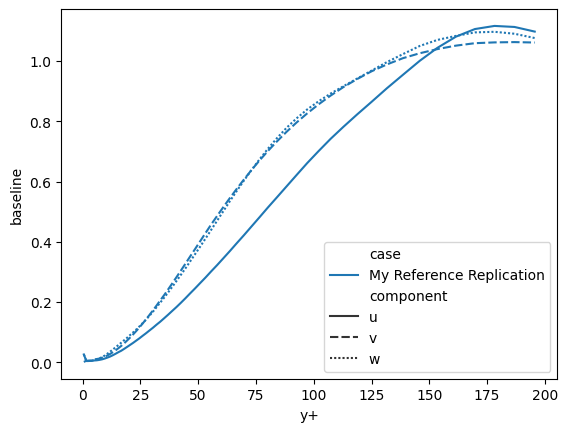

In [234]:
sns.lineplot(data=baseline, x="y+", y="baseline", hue="case", style="component")

In [245]:
bm["Accuracy Improvement (%)"] = (bm["baseline"] - bm["MSE U"]) / bm["baseline"] * 100

In [246]:
bm

,MSE U,component,y+,training_id,case,baseline,improvement_%,loss_%,Accuracy Improvement (%)
0,0.026105,u,0.555505,16,My Reference Replication,0.026105,0.000000,0.000000,0.000000
1,0.004175,u,1.667099,16,My Reference Replication,0.004175,0.000000,0.000000,0.000000
2,0.004429,u,2.780451,16,My Reference Replication,0.004429,0.000000,0.000000,0.000000
3,0.004620,u,3.896738,16,My Reference Replication,0.004620,0.000000,0.000000,0.000000
4,0.006069,u,5.017153,16,My Reference Replication,0.006069,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...
571,1.005626,w,161.500168,73,With Scale Filtering,1.083598,-7.195643,7.195643,7.195643
572,1.021156,w,169.741053,73,With Scale Filtering,1.095274,-6.767076,6.767076,6.767076
573,1.029721,w,178.211944,73,With Scale Filtering,1.097234,-6.152985,6.152985,6.152985
574,1.034046,w,186.855558,73,With Scale Filtering,1.090774,-5.200775,5.200775,5.200775


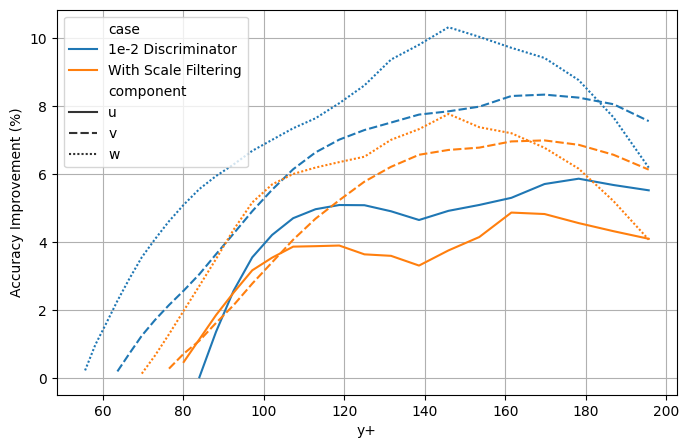

In [247]:
df = bm.where(bm["case"] != "My Reference Replication").where(bm["loss_%"] > 0)
plt.figure(figsize=(8, 5))
sns.lineplot(data=df, x="y+", y="Accuracy Improvement (%)", hue="case", style="component")
plt.legend()
plt.grid(True)
plt.show()

In [229]:
df[["y+", "case", "loss_%"]].dropna()

,y+,case,loss_%
589,5.017153,1e-2 Discriminator,12.922772
592,6.142901,1e-2 Discriminator,7.709621
593,6.142901,1e-2 Discriminator,1.158772
595,7.275210,1e-2 Discriminator,9.395904
596,7.275210,1e-2 Discriminator,13.728696
...,...,...,...
1338,186.855558,With Scale Filtering,4.313836
1340,186.855558,With Scale Filtering,2.336056
1341,195.606398,With Scale Filtering,4.090796
1342,195.606398,With Scale Filtering,0.810991


In [ ]:
import numpy as np
from space_exploration.beans.dataset_bean import Dataset
from space_exploration.dataset.transforms.AllTransforms import TransformationReferences
dataset_name = "re200-sr1etot"
dataset = Dataset.get_dataset_or_fail(dataset_name)
ds = dataset.get_training_dataset(64, TransformationReferences.DEFAULT_UNCHANGED.transformation, TransformationReferences.DEFAULT_UNCHANGED.transformation, size=1000)
# ds = dataset.get_training_dataset(64, TransformationReferences.COMPONENT_NORMALIZE.transformation, TransformationReferences.Y_ALONG_COMPONENT_NORMALIZE.transformation, size=10)
xs = np.array([x.numpy() for x, y in ds])
ys = np.array([y.numpy() for x, y in ds])

y_dim = dataset.channel.get_simulation_channel().y_dimension[:64] * 200

In [ ]:
plt.plot(y_dim, ys.std((0, 2, 4))[0], label="Reference Replication U")
plt.plot(y_dim, ys.std((0, 2, 4))[1], label="Reference Replication V")
plt.plot(y_dim, ys.std((0, 2, 4))[2], label="Reference Replication W")
plt.xlabel("y+")
plt.ylabel("Mean Standard Deviation")
plt.legend()
plt.grid()
plt.show()